In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [3]:
import itertools
from scipy.stats import wilcoxon
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        # * is p < 0.05
        # ** is p < 0.005
        # *** is p < 0.0005
        # etc.
        text = ''
        p = .05

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

In [4]:
metrics_dir=os.path.join(os.getcwd(),"metrics")
# --- LOAD THE .pkl FILE GENERATED PREVIOUSLY ---
adapt=[0,120,20,2]
test_ds_b4=False


combined_results=[]
combined_results_3=[]
for a in adapt:
    if test_ds_b4:
        identifier=f"testing_dsb4_adaptable{a}" if a > 0 else "testing_dsb4"
    else:
        identifier=f"30000_1000_100_adaptable{a}" if a > 0 else "30000_1000_100"
        # identifier="1000_200_median"
    filename = f"channel_metrics_by_network_{identifier}.csv"
    file_3=f"channel_metrics_by_network_{identifier}_3.csv"
    path = os.path.join(metrics_dir, filename)
    path_3 = os.path.join(metrics_dir, file_3)
    if os.path.exists(path):
        df = pd.read_csv(path)
        df["Adapt"] = a  # Add a column to identify the condition
        combined_results.append(df)
        df_3=pd.read_csv(path_3)
        df_3["Adapt"] = a
        combined_results_3.append(df_3)
        print(f"Loaded: {filename}")
    else:
        print(f"Missing: {filename}")


# Combine all into one DataFrame
all_results_df = pd.concat(combined_results, ignore_index=True)
all_results_df_3=pd.concat(combined_results_3, ignore_index=True)
print(all_results_df.head())
# Example usage:
print(all_results_df.groupby("Adapt")["F1"].mean())
print(all_results_df_3.groupby("Adapt")["F1"].mean())

Loaded: channel_metrics_by_network_30000_1000_100.csv
Loaded: channel_metrics_by_network_30000_1000_100_adaptable120.csv
Loaded: channel_metrics_by_network_30000_1000_100_adaptable20.csv
Loaded: channel_metrics_by_network_30000_1000_100_adaptable2.csv
                   Network                     Dataset  Channel   TP   FP  FN  \
0  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        0  215  786   9   
1  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        1  203  480  21   
2  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        2  183  259  41   
3  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        3  146  112  78   
4  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        4  142  178  82   

   Precision    Recall        F1  Adapt  
0   0.214785  0.959821  0.351020      0  
1   0.297218  0.906250  0.447630      0  
2   0.414027  0.816964  0.549550      0  
3   0.565891  0.651786  0.605809      0  
4   0.443750  0.633929  0.522059      0  
Adapt
0  

In [4]:
dataset_colors={
   "Amigo": "#8E44AD",
   "Dlx": "#E74C3C",
   "Som": "#FFC300",
   "Thy": "#17BECF"
}

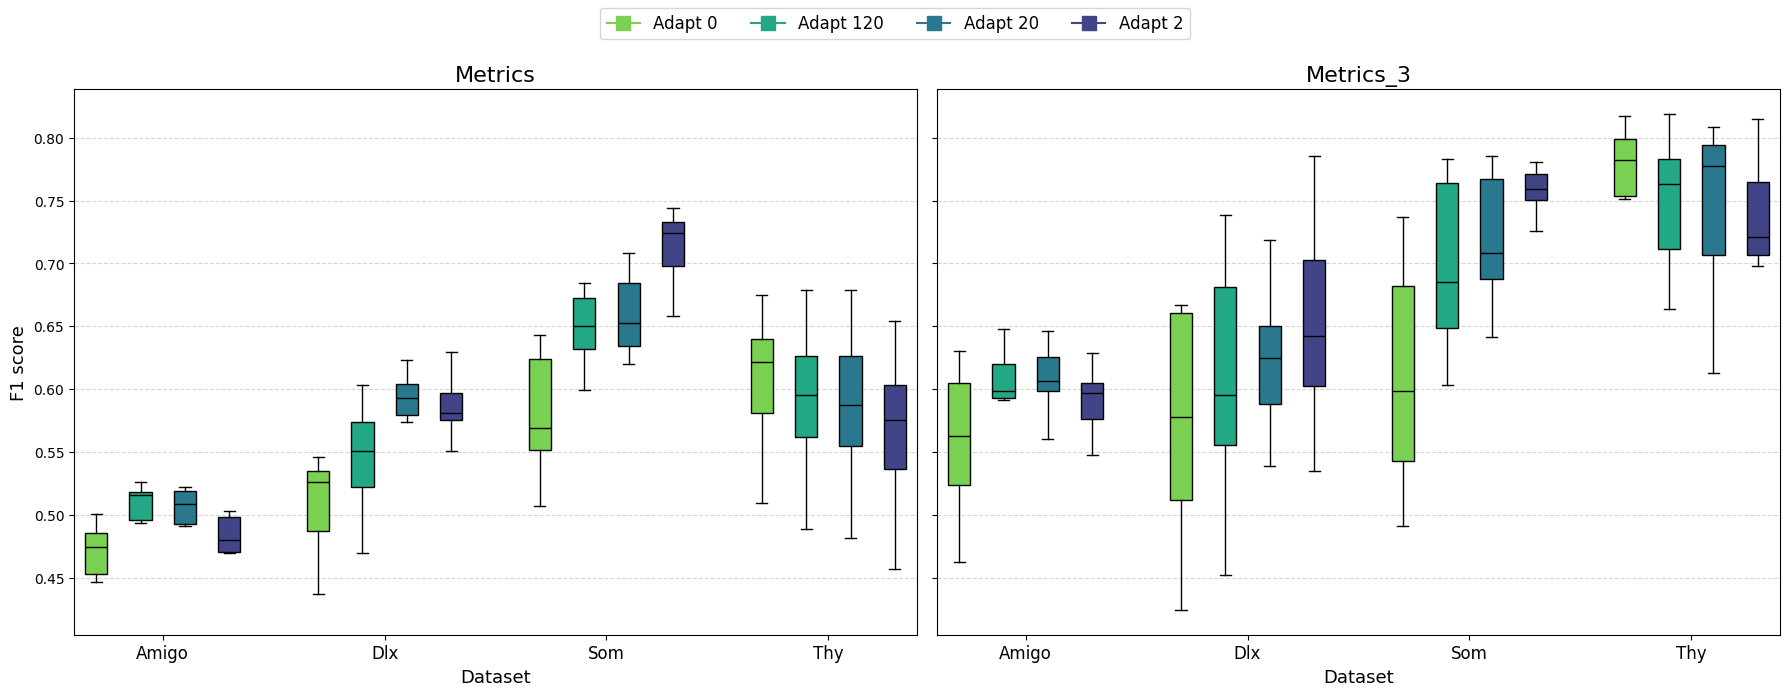

In [5]:
def plot_two_f1_boxplots(df1, df2, avg_within_dataset=True, back_colors=None):
    adapt_values = [0, 120, 20, 2]
    datasets = sorted(df1["Dataset"].unique())
    n_adapt = len(adapt_values)
    colors = plt.cm.viridis_r(np.linspace(0.2, 0.8, n_adapt))
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
    
    def plot_df(ax, df, datasets, title, avg_within_dataset, force_avg=False):
        positions = []
        data = []
        
        for i, dataset in enumerate(datasets):
            subset = df[df["Dataset"] == dataset]
            
            if avg_within_dataset or force_avg:
                subset = subset.groupby(["Network", "Adapt"])["F1"].mean().reset_index()
                pivot_index = "Network"
            else:
                subset = subset.groupby(["Network", "Dataset", "Channel", "Adapt"])["F1"].mean().reset_index()
                pivot_index = ["Network", "Channel"]

            pivot = subset.pivot(index=pivot_index, columns="Adapt", values="F1").reindex(columns=adapt_values)
            
            for j, adapt in enumerate(adapt_values):
                vals = pivot[adapt].dropna().values
                pos = i * (n_adapt + 1) + j
                data.append(vals)
                positions.append(pos)
        
        # --- Boxplots ---
        for idx, (vals, pos) in enumerate(zip(data, positions)):
            color = colors[idx % n_adapt]
            bplot = ax.boxplot(vals, positions=[pos], widths=0.5, patch_artist=True,
                               showfliers=False, medianprops=dict(color='black'))
            for patch in bplot['boxes']:
                patch.set_facecolor(color)
        
        # --- Background shading ---
        if back_colors:
            for i, dataset in enumerate(datasets):
                if dataset in back_colors:
                    start = i * (n_adapt + 1) - 0.5
                    end = start + n_adapt
                    ax.axvspan(start, end, color=back_colors[dataset], alpha=0.15, zorder=0)
        
        # --- X-axis labels ---
        xticks = [i * (n_adapt + 1) + (n_adapt - 1) / 2 for i in range(len(datasets))]
        ax.set_xticks(xticks)
        labels=["Amigo","Dlx","Som","Thy"]
        ax.set_xticklabels(labels, fontsize=12)
        
        ax.set_xlabel("Dataset", fontsize=13)
        ax.set_title(title, fontsize=16)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Left = df1 (with toggle)
    plot_df(axes[0], df1, datasets, "Metrics", avg_within_dataset, force_avg=False)
    axes[0].set_ylabel("F1 score", fontsize=13)
    
    # Right = df2 (force averaged)
    plot_df(axes[1], df2, datasets, "Metrics_3", avg_within_dataset, force_avg=True)
    
    # Legend (shared)
    adapt_labels = [f"Adapt {a}" for a in adapt_values]
    legend_patches = [
        plt.Line2D([0], [0], color=colors[i], marker='s', markersize=10, label=adapt_labels[i])
        for i in range(n_adapt)
    ]
    fig.legend(handles=legend_patches, fontsize=12, loc='upper center', ncol=len(adapt_values))
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


# Example usage:
plot_two_f1_boxplots(all_results_df, all_results_df_3, avg_within_dataset=True, back_colors=dataset_colors)


In [6]:
from scipy.stats import wilcoxon

def compare_df1_df2_by_adapt(df1, df2):
    adapt_values = [0, 120, 20, 2]
    
    # Average df1 within dataset per network for fair comparison
    df1_avg = df1.groupby(["Network", "Dataset", "Adapt"])["F1"].mean().reset_index()
    df2_avg = df2.groupby(["Network", "Dataset", "Adapt"])["F1"].mean().reset_index()

    for adapt in adapt_values:
        vals1 = df1_avg[df1_avg["Adapt"] == adapt]
        vals2 = df2_avg[df2_avg["Adapt"] == adapt]

        # Merge to align Network/Dataset pairs
        merged = pd.merge(
            vals1, vals2,
            on=["Network", "Dataset", "Adapt"],
            suffixes=("_df1", "_df2")
        )

        if merged.shape[0] > 0:
            stat, p = wilcoxon(merged["F1_df1"], merged["F1_df2"])
            print(f"Adapt {adapt}: Wilcoxon stat={stat:.4f}, p={p:.4e}, n={len(merged)}")
        else:
            print(f"Adapt {adapt}: no matching pairs found.")

# Example usage:
compare_df1_df2_by_adapt(all_results_df, all_results_df_3)


Adapt 0: Wilcoxon stat=29.0000, p=1.2356e-11, n=48
Adapt 120: Wilcoxon stat=10.0000, p=3.0553e-13, n=48
Adapt 20: Wilcoxon stat=14.0000, p=7.8160e-13, n=48
Adapt 2: Wilcoxon stat=12.0000, p=4.9738e-13, n=48


In [14]:
recall=51.28
precision=68.55
f1=2*precision*recall/(precision+recall)
print(f1)

58.670516565133944


In [69]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import itertools
from scipy.stats import mannwhitneyu,wilcoxon
from matplotlib.patches import Patch

def holm_bonferroni(p_values, alpha=0.05):
    """Apply Holm–Bonferroni correction to a list of p-values."""
    m = len(p_values)
    sorted_indices = np.argsort(p_values)
    sorted_pvals = np.array(p_values)[sorted_indices]
    reject = np.zeros(m, dtype=bool)
    adjusted_pvals = np.zeros(m)

    for k, p in enumerate(sorted_pvals):
        threshold = alpha / (m - k)
        if p <= threshold:
            reject[sorted_indices[k]] = True
        adjusted_pvals[sorted_indices[k]] = min(p * (m - k), 1.0)

    return adjusted_pvals, reject

def get_network_means(df, metrics=["Precision", "Recall", "F1"]):
    """Average across channels per dataset per network."""
    return df.groupby(["Dataset", "Network"])[metrics].mean().reset_index()

def plot_adapt_comparison(df_ref, df_other, metrics=["Precision","Recall","F1"],
                          labels=("Adapt 0","Other"), colors=None, alpha=0.05):
    """
    Compare metrics from two dataframes (averaged per network).
    df_ref = dataframe with Adapt=0
    df_other = dataframe with another condition
    """
    back_colors = {
        "Precision": "lightblue",
        "Recall": "lightgreen",
        "F1": "lightcoral"
    }
    if colors is None:
        colors = {labels[0]: "#BCBFC2FF", labels[1]: "#535352"}

    # Aggregate by network
    grouped_ref = get_network_means(df_ref, metrics)
    grouped_other = get_network_means(df_other, metrics)

    fig, ax = plt.subplots(figsize=(9,6))
    width = 0.5
    spacing = 2
    xticks, xticklabels = [], []
    positions, data, plot_colors, box_heights = [], [], [], []

    for i, metric in enumerate(metrics):
        base_pos = i * spacing
        vals_ref = grouped_ref[metric].dropna().values
        vals_other = grouped_other[metric].dropna().values

        vals = [vals_ref, vals_other]
        labs = [labels[0], labels[1]]

        # symmetric offsets around the base position
        offsets = [-0.3, 0.3]  

        for j, (v, lab) in enumerate(zip(vals, labs)):
            pos = base_pos + offsets[j]
            positions.append(pos)
            data.append(v)
            plot_colors.append(colors[lab])

        xticks.append(base_pos)
        xticklabels.append(metric)

        # Background shading centered around the metric group
        if back_colors and metric in back_colors:
            ax.axvspan(base_pos - 0.7, base_pos + 0.7,
                    color=back_colors.get(metric, "lightgray"), alpha=0.2)
        else:
            ax.axvspan(base_pos - 0.7, base_pos + 0.7,
                    color="lightgray", alpha=0.1)
    # Plot boxplots
    for pos, vals, c in zip(positions, data, plot_colors):
        bplot = ax.boxplot(vals, positions=[pos], widths=width,
                           patch_artist=True, showfliers=False,
                           medianprops=dict(color='black'))
        for patch in bplot['boxes']:
            patch.set_facecolor(c)
        box_heights.append(np.max(vals) if len(vals) > 0 else 0)

    # Statistics
    for i, metric in enumerate(metrics):
        idx_ref = i*2
        idx_other = i*2 + 1
        vals_ref, vals_other = data[idx_ref], data[idx_other]
        pos_ref, pos_other = positions[idx_ref], positions[idx_other]

        if len(vals_ref) > 0 and len(vals_other) > 0:
            # _, p = mannwhitneyu(vals_ref, vals_other, alternative="two-sided")
            _,p=wilcoxon(vals_ref, vals_other, alternative="two-sided")
        else:
            p = 1.0
        print(f"{metric}: p-value = {p:.4e}")
        # annotate
        barplot_annotate_brackets(0, 1, p,
                                  [pos_ref,pos_other],
                                  [box_heights[idx_ref],box_heights[idx_other]],
                                  ax,dh=0.03,barh=0.00)

    # Formatting
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=14)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_ylabel("Score", fontsize=14)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.5)
    for spine in ["top","right"]:
        ax.spines[spine].set_visible(False)

    # Legend
    # legend_patches = [Patch(color=colors[lab], label=lab) for lab in labels]
    # ax.legend(handles=legend_patches, loc="lower right")

    plt.tight_layout()
    return fig, ax


Precision: p-value = 6.2273e-02
Recall: p-value = 7.1054e-15
F1: p-value = 1.2356e-11


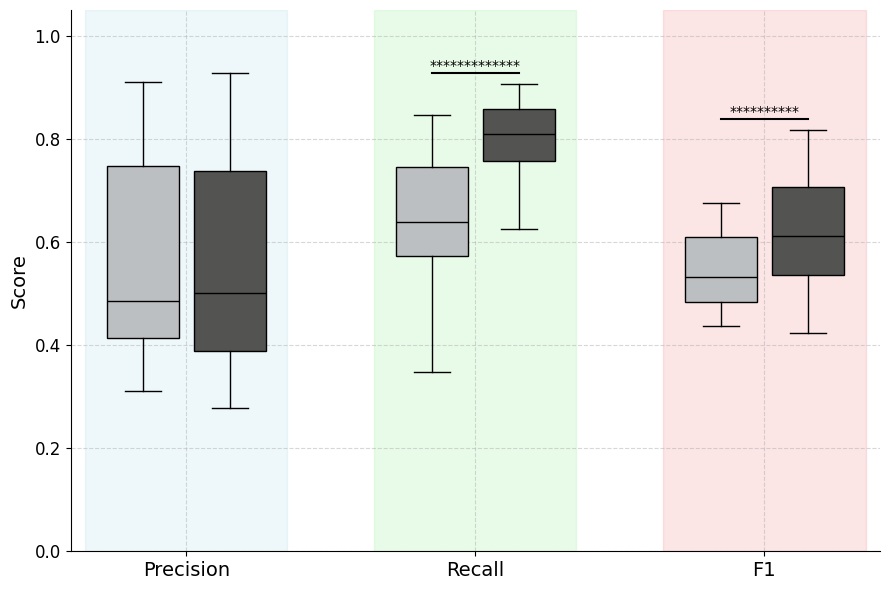

In [70]:
df_adapt0 = all_results_df[all_results_df["Adapt"]==0]
df_adapt0_3=all_results_df_3[all_results_df_3["Adapt"]==0]
fig, ax = plot_adapt_comparison(df_adapt0, df_adapt0_3, labels=("Single","Parallel"))
fig.savefig(os.path.join("figures","adapt_comparison.png"), bbox_inches="tight", dpi=300)
